# 01 — Baseline characteristics of the analytic sample (Table 1)

**Purpose:** describe the analytic sample of Brazilian infants aged 6–24 months from ENANI-2019, stratified by iron supplementation status (any iron-containing supplement use in the preceding six months).

**Outputs:**
- A standard Table 1 of demographic, socioeconomic, obstetric, maternal, feeding, and co-supplementation characteristics, by exposure group, with 95% CIs for proportions, standardized mean differences (SMDs), and group-comparison p-values.
- A STROBE-style sample flow diagram from the full ENANI-2019 child file (n = 14,558) to the analytic sample (n = 4,601).
- A bar chart of categorical distributions by exposure group.

**Notes:**
- This notebook is descriptive only. No causal claim is made.
- Tests are reported for transparency. SMD is the preferred summary of imbalance because it is unaffected by sample size and is the standard input to subsequent IPTW/IPCW analyses.
- |SMD| < 0.10 conventionally indicates negligible imbalance; |SMD| ≥ 0.10 flags a confounder for which adjustment is likely necessary.
- Variables with substantial missingness are reported with the number of non-missing observations per group; missingness handling for the adjusted-inference stage is documented in `Manuscript/methods.md`.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('../Data/data_crianca_calib_anon.csv')
assert DATA_PATH.exists()
print(f'Data path: {DATA_PATH.resolve()}')

Data path: /Users/marcelocarvalhoesilva/project/IronBrazil/Data/data_crianca_calib_anon.csv


## Helper functions

Wilson CI for proportions, standardized mean difference (SMD), and a two-group testing helper.

In [2]:
Z95 = 1.959964

def wilson_ci(events, n):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = events / n
    z = Z95
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half_width = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return p, max(0.0, centre - half_width), min(1.0, centre + half_width)

def smd_continuous(g0, g1):
    g0 = pd.Series(g0).dropna()
    g1 = pd.Series(g1).dropna()
    if len(g0) < 2 or len(g1) < 2:
        return np.nan
    s0sq = g0.var(ddof=1)
    s1sq = g1.var(ddof=1)
    pooled = np.sqrt((s0sq + s1sq) / 2)
    if pooled == 0:
        return np.nan
    return (g1.mean() - g0.mean()) / pooled

def smd_binary(p0, p1):
    pooled = np.sqrt((p0 * (1 - p0) + p1 * (1 - p1)) / 2)
    if pooled == 0:
        return np.nan
    return (p1 - p0) / pooled

def fmt_n_pct_ci(events, n):
    if n == 0:
        return '—'
    p, lo, hi = wilson_ci(events, n)
    return f'{events} ({p*100:.1f}) [{lo*100:.1f}, {hi*100:.1f}]'

def fmt_mean_sd(values):
    s = pd.Series(values).dropna()
    if len(s) < 2:
        return '—'
    return f'{s.mean():.2f} ({s.std(ddof=1):.2f})'

def fmt_median_iqr(values):
    s = pd.Series(values).dropna()
    if len(s) < 2:
        return '—'
    return f'{s.median():.2f} [{s.quantile(0.25):.2f}, {s.quantile(0.75):.2f}]'

## 1. Sample flow and exposure

In [3]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
n_total = len(raw)
raw['age_months'] = raw['b05a_idade_em_meses'].astype(str).str.extract(r'(\d+)').astype(float)
n_age_known = raw['age_months'].notna().sum()
df = raw[(raw['age_months'] >= 6) & (raw['age_months'] <= 24)].copy()
n_eligible = len(df)
df['iron_any'] = (df['vd_supl1_com_ferro'] == 'Sim').astype(int)
n_unexposed = int((df['iron_any'] == 0).sum())
n_exposed = int((df['iron_any'] == 1).sum())

print(f'ENANI-2019 child file:                {n_total:,}')
print(f'  with valid age in months:           {n_age_known:,}')
print(f'  aged 6–24 months (analytic sample): {n_eligible:,}')
print(f'    unexposed (no iron supplement):   {n_unexposed:,} ({n_unexposed/n_eligible*100:.1f}%)')
print(f'    exposed (any iron supplement):    {n_exposed:,} ({n_exposed/n_eligible*100:.1f}%)')

ENANI-2019 child file:                14,558
  with valid age in months:           14,558
  aged 6–24 months (analytic sample): 4,601
    unexposed (no iron supplement):   3,248 (70.6%)
    exposed (any iron supplement):    1,353 (29.4%)


## 2. Variable construction

All variables follow the codebook used throughout the project. Categorical variables are recoded into binary indicators where appropriate; multi-level categorical variables (region, education, IEN quintile, EBIA category) preserve all levels.

Co-supplementation indicators (vitamin A, vitamin D, multivitamin) are included so that any later analysis comparing iron-only versus iron-with-other-micronutrients exposure can rely on the same panel of baseline characteristics.

In [4]:
df['male'] = (df['b02_sexo'] == 'Masculino').astype(int)

race_map = {
    'Branca': 'White',
    'Preta': 'Black',
    'Parda (mulata, cabocla, cafuza, mameluca ou mestiça)': 'Mixed/Parda',
    'Indígena': 'Indigenous',
    'Amarela (origem japonesa, chinesa, coreana etc.)': 'Asian',
}
df['race_cat'] = df['d01_cor'].map(race_map).fillna('Unknown')

df['region'] = df['a00_regiao']
df['urban'] = (df['a11_situacao'] == 'Urbano').astype(int)

def educ_band(text):
    if pd.isna(text):
        return 'Unknown'
    t = str(text)
    if 'Sem estudo' in t:
        return 'Less than primary'
    if 'fundamental' in t.lower():
        m = re.search(r'(\d+)', t)
        if m and int(m.group(1)) >= 8:
            return 'Primary completed'
        return 'Less than primary'
    if 'ensino médio' in t.lower():
        if '3°ano' in t or '3° ano' in t:
            return 'Secondary completed'
        return 'Primary completed'
    if 'superior' in t.lower():
        return 'Tertiary or above'
    return 'Unknown'
import re
df['education'] = df['j10_serie'].apply(educ_band)

df['ien_quintile'] = pd.to_numeric(df['vd_ien_quintos'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df['food_insecurity'] = df['vd_ebia_categ']

df['sanitation_adequate'] = df['p10_esgoto'].isin([
    'Rede geral de esgoto ou pluvial',
    'Fossa séptica ligada a rede',
    'Fossa séptica não ligada a rede',
]).astype(int)

df['water_network'] = (df['p11_agua'] == 'Rede geral de distribuição').astype(int)

df['cesarean'] = df['h04_parto'].isin([
    'Cesariana agendada (eletiva)', 'Cesariana de urgência (não agendada)',
]).astype(int)

df['birth_weight'] = pd.to_numeric(df['h02_peso'], errors='coerce')
df['low_birth_weight'] = (df['birth_weight'] < 2500).astype('Int64')
df.loc[df['birth_weight'].isna(), 'low_birth_weight'] = pd.NA

df['gest_weeks'] = pd.to_numeric(df['h01_semanas_gravidez'], errors='coerce')
df['preterm'] = (df['gest_weeks'] < 37).astype('Int64')
df.loc[df['gest_weeks'].isna(), 'preterm'] = pd.NA

df['prenatal_visits'] = pd.to_numeric(df['k05_prenatal_consultas'], errors='coerce')

df['maternal_age'] = pd.to_numeric(df['bb04_idade_da_mae'], errors='coerce')

df['breastfed_now'] = (df['e01_leite_peito'] == 'Sim').astype(int)
df['formula_now'] = (df['e10_formula_infantil'] == 'Sim').astype(int)
df['cow_milk_now'] = ((df['e06_leite_vaca_po'] == 'Sim') | (df['e07_leite_vaca_liquido'] == 'Sim')).astype(int)
df['exclusive_bf'] = ((df['breastfed_now'] == 1) & (df['formula_now'] == 0) & (df['cow_milk_now'] == 0)).astype(int)
df['mixed_feeding'] = ((df['breastfed_now'] == 1) & ((df['formula_now'] == 1) | (df['cow_milk_now'] == 1))).astype(int)

df['supp_vita'] = (df['vd_supl1_com_vita'] == 'Sim').astype(int) if 'vd_supl1_com_vita' in df.columns else 0
df['supp_vitd'] = (df['vd_supl1_com_vitd'] == 'Sim').astype(int) if 'vd_supl1_com_vitd' in df.columns else 0
df['supp_multi'] = (df['vd_supl1_multivitaminico_com_minerais'] == 'Sim').astype(int) if 'vd_supl1_multivitaminico_com_minerais' in df.columns else 0

def age_band(m):
    if pd.isna(m):
        return 'Unknown'
    if m < 12:
        return '6–11 mo'
    if m < 18:
        return '12–17 mo'
    return '18–24 mo'
df['age_band'] = df['age_months'].apply(age_band)

print('Variables constructed.')

Variables constructed.


## 3. Build Table 1

For each characteristic we report: total column (n=4601), unexposed column, exposed column, group-comparison test, p-value, and SMD. Continuous variables use mean (SD); categorical variables use n (% [95% Wilson CI]).

Tests: chi-square for categorical (Fisher's exact when any expected cell count < 5); Welch t-test for continuous; SMD computed throughout.

In [5]:
def add_continuous_row(df, var, label, rows):
    s_total = df[var].dropna()
    s0 = df.loc[df['iron_any'] == 0, var].dropna()
    s1 = df.loc[df['iron_any'] == 1, var].dropna()
    n_total_obs = len(s_total)
    if len(s0) < 2 or len(s1) < 2:
        rows.append({'Characteristic': label, 'Total': fmt_mean_sd(s_total),
                     'Unexposed': fmt_mean_sd(s0), 'Exposed': fmt_mean_sd(s1),
                     'N (obs)': n_total_obs, 'Test': '—', 'p-value': '—', 'SMD': '—'})
        return
    welch = stats.ttest_ind(s0, s1, equal_var=False)
    smd = smd_continuous(s0, s1)
    rows.append({
        'Characteristic': label,
        'Total': fmt_mean_sd(s_total),
        'Unexposed': fmt_mean_sd(s0),
        'Exposed': fmt_mean_sd(s1),
        'N (obs)': n_total_obs,
        'Test': 'Welch t',
        'p-value': f'{welch.pvalue:.4f}',
        'SMD': f'{smd:+.3f}',
    })

def add_binary_row(df, var, label, rows, indent=False):
    sub = df[[var, 'iron_any']].dropna()
    sub[var] = sub[var].astype(int)
    n0 = int((sub['iron_any'] == 0).sum())
    n1 = int((sub['iron_any'] == 1).sum())
    n_total_obs = n0 + n1
    e0 = int(sub.loc[sub['iron_any'] == 0, var].sum())
    e1 = int(sub.loc[sub['iron_any'] == 1, var].sum())
    e_tot = e0 + e1
    if n0 < 5 or n1 < 5:
        rows.append({'Characteristic': ('  ' if indent else '') + label,
                     'Total': '—', 'Unexposed': '—', 'Exposed': '—',
                     'N (obs)': n_total_obs, 'Test': '—', 'p-value': '—', 'SMD': '—'})
        return
    table = pd.crosstab(sub['iron_any'], sub[var])
    if (table.values < 5).any():
        _, p = stats.fisher_exact(table.values)
        method = 'Fisher'
    else:
        _, p, _, _ = stats.chi2_contingency(table.values, correction=False)
        method = 'Chi²'
    p0 = e0 / n0
    p1 = e1 / n1
    smd = smd_binary(p0, p1)
    rows.append({
        'Characteristic': ('  ' if indent else '') + label,
        'Total': fmt_n_pct_ci(e_tot, n_total_obs),
        'Unexposed': fmt_n_pct_ci(e0, n0),
        'Exposed': fmt_n_pct_ci(e1, n1),
        'N (obs)': n_total_obs,
        'Test': method,
        'p-value': f'{p:.4f}',
        'SMD': f'{smd:+.3f}',
    })

def add_categorical_block(df, var, label, rows, level_order=None):
    sub = df[[var, 'iron_any']].dropna()
    levels = level_order if level_order is not None else sorted(sub[var].dropna().unique())
    table = pd.crosstab(sub['iron_any'], sub[var])
    full_table = table.reindex(columns=levels, fill_value=0)
    if full_table.values.sum() < 10:
        return
    if (full_table.values < 5).any():
        try:
            _, p = stats.fisher_exact(full_table.values) if full_table.shape[1] == 2 else (None, np.nan)
            method = 'Fisher'
        except Exception:
            _, p, _, _ = stats.chi2_contingency(full_table.values, correction=False)
            method = 'Chi²'
    else:
        _, p, _, _ = stats.chi2_contingency(full_table.values, correction=False)
        method = 'Chi²'
    rows.append({
        'Characteristic': label,
        'Total': '', 'Unexposed': '', 'Exposed': '',
        'N (obs)': int(full_table.values.sum()),
        'Test': method,
        'p-value': f'{p:.4f}',
        'SMD': '',
    })
    n0_total = int((sub['iron_any'] == 0).sum())
    n1_total = int((sub['iron_any'] == 1).sum())
    for level in levels:
        if level not in full_table.columns:
            continue
        e0 = int(full_table.loc[0, level]) if 0 in full_table.index else 0
        e1 = int(full_table.loc[1, level]) if 1 in full_table.index else 0
        e_tot = e0 + e1
        n_tot = n0_total + n1_total
        p0 = e0 / n0_total if n0_total > 0 else np.nan
        p1 = e1 / n1_total if n1_total > 0 else np.nan
        smd = smd_binary(p0, p1)
        rows.append({
            'Characteristic': '  ' + str(level),
            'Total': fmt_n_pct_ci(e_tot, n_tot),
            'Unexposed': fmt_n_pct_ci(e0, n0_total),
            'Exposed': fmt_n_pct_ci(e1, n1_total),
            'N (obs)': '',
            'Test': '',
            'p-value': '',
            'SMD': f'{smd:+.3f}',
        })

rows = []
rows.append({'Characteristic': '— Demographic —', 'Total': '', 'Unexposed': '', 'Exposed': '', 'N (obs)': '', 'Test': '', 'p-value': '', 'SMD': ''})
add_continuous_row(df, 'age_months', 'Age, months — mean (SD)', rows)
add_categorical_block(df, 'age_band', 'Age band — n (%) [95% CI]', rows, level_order=['6–11 mo', '12–17 mo', '18–24 mo'])
add_binary_row(df, 'male', 'Male — n (%) [95% CI]', rows)
add_categorical_block(df, 'race_cat', 'Race / colour — n (%) [95% CI]', rows, level_order=['White', 'Mixed/Parda', 'Black', 'Indigenous', 'Asian', 'Unknown'])
add_categorical_block(df, 'region', 'Region — n (%) [95% CI]', rows, level_order=['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste'])
add_binary_row(df, 'urban', 'Urban setting — n (%) [95% CI]', rows)

rows.append({'Characteristic': '— Socioeconomic —', 'Total': '', 'Unexposed': '', 'Exposed': '', 'N (obs)': '', 'Test': '', 'p-value': '', 'SMD': ''})
add_categorical_block(df, 'education', 'Maternal education — n (%) [95% CI]', rows, level_order=['Less than primary', 'Primary completed', 'Secondary completed', 'Tertiary or above', 'Unknown'])
add_continuous_row(df, 'ien_quintile', 'IEN quintile (1 = poorest, 5 = wealthiest) — mean (SD)', rows)
add_categorical_block(df, 'food_insecurity', 'Food insecurity (EBIA) — n (%) [95% CI]', rows, level_order=['Segurança', 'Insegurança leve', 'Insegurança moderada', 'Insegurança grave'])
add_binary_row(df, 'sanitation_adequate', 'Adequate sanitation — n (%) [95% CI]', rows)
add_binary_row(df, 'water_network', 'Water from public network — n (%) [95% CI]', rows)

rows.append({'Characteristic': '— Obstetric —', 'Total': '', 'Unexposed': '', 'Exposed': '', 'N (obs)': '', 'Test': '', 'p-value': '', 'SMD': ''})
add_continuous_row(df, 'birth_weight', 'Birth weight, g — mean (SD)', rows)
add_binary_row(df, 'low_birth_weight', 'Low birth weight (< 2500 g) — n (%) [95% CI]', rows)
add_continuous_row(df, 'gest_weeks', 'Gestational age, weeks — mean (SD)', rows)
add_binary_row(df, 'preterm', 'Preterm (< 37 weeks) — n (%) [95% CI]', rows)
add_binary_row(df, 'cesarean', 'Caesarean delivery — n (%) [95% CI]', rows)
add_continuous_row(df, 'prenatal_visits', 'Prenatal visits — mean (SD)', rows)

rows.append({'Characteristic': '— Maternal —', 'Total': '', 'Unexposed': '', 'Exposed': '', 'N (obs)': '', 'Test': '', 'p-value': '', 'SMD': ''})
add_continuous_row(df, 'maternal_age', 'Maternal age, years — mean (SD)', rows)

rows.append({'Characteristic': '— Feeding —', 'Total': '', 'Unexposed': '', 'Exposed': '', 'N (obs)': '', 'Test': '', 'p-value': '', 'SMD': ''})
add_binary_row(df, 'breastfed_now', 'Currently breastfeeding — n (%) [95% CI]', rows)
add_binary_row(df, 'formula_now', 'Currently using formula — n (%) [95% CI]', rows)
add_binary_row(df, 'cow_milk_now', 'Currently consuming cow milk — n (%) [95% CI]', rows)
add_binary_row(df, 'exclusive_bf', 'Exclusive breastfeeding (BF, no formula or cow milk) — n (%) [95% CI]', rows)
add_binary_row(df, 'mixed_feeding', 'Mixed feeding (BF + formula or cow milk) — n (%) [95% CI]', rows)

rows.append({'Characteristic': '— Co-supplementation —', 'Total': '', 'Unexposed': '', 'Exposed': '', 'N (obs)': '', 'Test': '', 'p-value': '', 'SMD': ''})
add_binary_row(df, 'supp_vita', 'Vitamin A supplement (past 6 mo) — n (%) [95% CI]', rows)
add_binary_row(df, 'supp_vitd', 'Vitamin D supplement (past 6 mo) — n (%) [95% CI]', rows)
add_binary_row(df, 'supp_multi', 'Multivitamin with minerals (past 6 mo) — n (%) [95% CI]', rows)

table1 = pd.DataFrame(rows).set_index('Characteristic')
table1

,Total,Unexposed,Exposed,N (obs),Test,p-value,SMD
Characteristic,,,,,,,
— Demographic —,,,,,,,
"Age, months — mean (SD)",15.08 (5.45),15.28 (5.54),14.59 (5.20),4601,Welch t,0.0001,-0.129
Age band — n (%) [95% CI],,,,4601,Chi²,0.0004,
6–11 mo,"1415 (30.8) [29.4, 32.1]","974 (30.0) [28.4, 31.6]","441 (32.6) [30.1, 35.1]",,,,+0.056
12–17 mo,"1477 (32.1) [30.8, 33.5]","1009 (31.1) [29.5, 32.7]","468 (34.6) [32.1, 37.2]",,,,+0.075
18–24 mo,"1709 (37.1) [35.8, 38.6]","1265 (38.9) [37.3, 40.6]","444 (32.8) [30.4, 35.4]",,,,-0.128
Male — n (%) [95% CI],"2360 (51.3) [49.8, 52.7]","1644 (50.6) [48.9, 52.3]","716 (52.9) [50.3, 55.6]",4601,Chi²,0.1543,+0.046
Race / colour — n (%) [95% CI],,,,4601,Fisher,nan,
White,"2028 (44.1) [42.6, 45.5]","1389 (42.8) [41.1, 44.5]","639 (47.2) [44.6, 49.9]",,,,+0.090


## 4. Visual summaries

Sample flow diagram (STROBE-style) and a forest-style display of SMDs to make balance/imbalance visible at a glance.

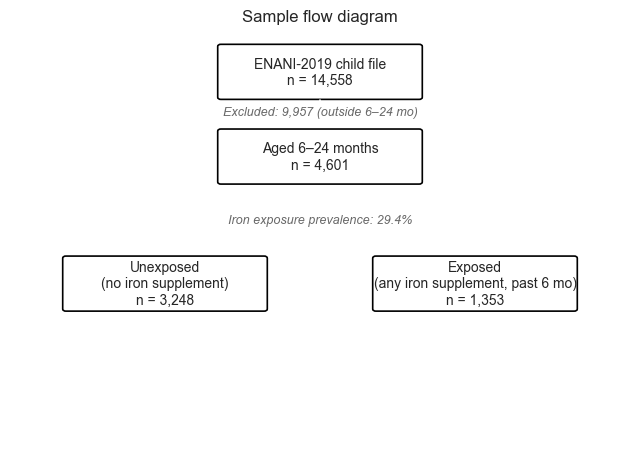

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

boxes = [
    (5, 9, f'ENANI-2019 child file\nn = {n_total:,}'),
    (5, 7, f'Aged 6–24 months\nn = {n_eligible:,}'),
    (2.5, 4, f'Unexposed\n(no iron supplement)\nn = {n_unexposed:,}'),
    (7.5, 4, f'Exposed\n(any iron supplement, past 6 mo)\nn = {n_exposed:,}'),
]
for x, y, text in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x - 1.6, y - 0.6), 3.2, 1.2, boxstyle='round,pad=0.05', linewidth=1.2, edgecolor='black', facecolor='white'))
    ax.text(x, y, text, ha='center', va='center', fontsize=10)

ax.annotate('', xy=(5, 7.7), xytext=(5, 8.4), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.annotate('', xy=(2.5, 4.7), xytext=(4, 6.3), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.annotate('', xy=(7.5, 4.7), xytext=(6, 6.3), arrowprops=dict(arrowstyle='->', lw=1.2))

ax.text(5, 8.05, f'Excluded: {n_total - n_eligible:,} (outside 6–24 mo)', ha='center', va='center', fontsize=9, style='italic', color='dimgray')
ax.text(5, 5.5, f'Iron exposure prevalence: {n_exposed/n_eligible*100:.1f}%', ha='center', va='center', fontsize=9, style='italic', color='dimgray')

ax.set_title('Sample flow diagram')
plt.show()

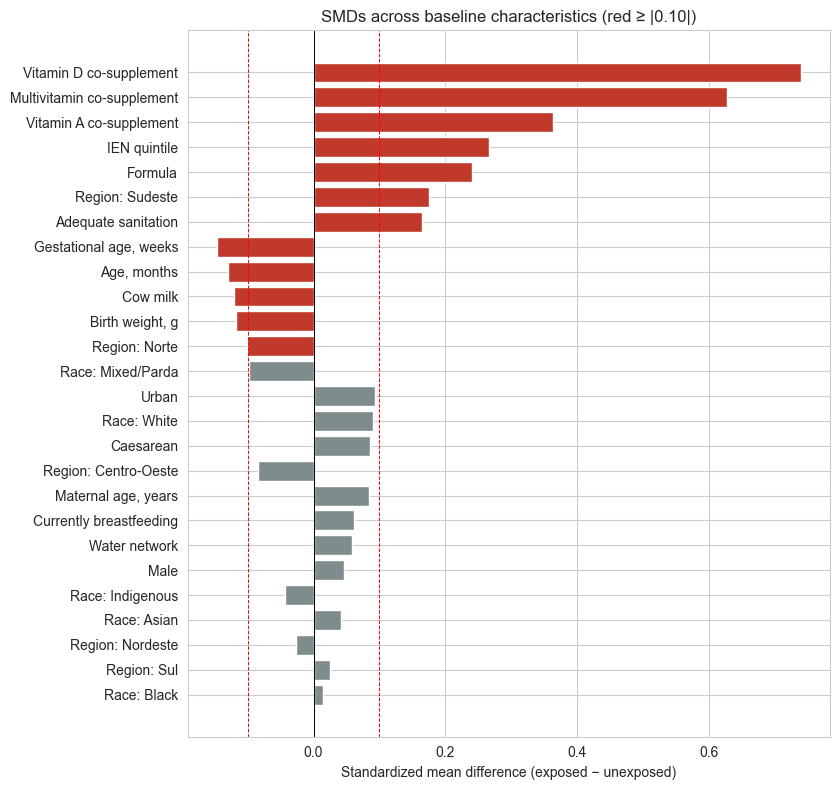

In [7]:
smd_rows = []
def collect_smd(label, smd):
    if pd.isna(smd):
        return
    smd_rows.append({'Variable': label, 'SMD': smd})

collect_smd('Age, months', smd_continuous(df.loc[df['iron_any']==0,'age_months'], df.loc[df['iron_any']==1,'age_months']))
collect_smd('Male', smd_binary(df.loc[df['iron_any']==0,'male'].mean(), df.loc[df['iron_any']==1,'male'].mean()))
for level in ['White','Mixed/Parda','Black','Indigenous','Asian']:
    p0 = (df.loc[df['iron_any']==0,'race_cat']==level).mean()
    p1 = (df.loc[df['iron_any']==1,'race_cat']==level).mean()
    collect_smd(f'Race: {level}', smd_binary(p0, p1))
for level in ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']:
    p0 = (df.loc[df['iron_any']==0,'region']==level).mean()
    p1 = (df.loc[df['iron_any']==1,'region']==level).mean()
    collect_smd(f'Region: {level}', smd_binary(p0, p1))
collect_smd('Urban', smd_binary(df.loc[df['iron_any']==0,'urban'].mean(), df.loc[df['iron_any']==1,'urban'].mean()))
collect_smd('IEN quintile', smd_continuous(df.loc[df['iron_any']==0,'ien_quintile'], df.loc[df['iron_any']==1,'ien_quintile']))
collect_smd('Adequate sanitation', smd_binary(df.loc[df['iron_any']==0,'sanitation_adequate'].mean(), df.loc[df['iron_any']==1,'sanitation_adequate'].mean()))
collect_smd('Water network', smd_binary(df.loc[df['iron_any']==0,'water_network'].mean(), df.loc[df['iron_any']==1,'water_network'].mean()))
collect_smd('Birth weight, g', smd_continuous(df.loc[df['iron_any']==0,'birth_weight'], df.loc[df['iron_any']==1,'birth_weight']))
collect_smd('Gestational age, weeks', smd_continuous(df.loc[df['iron_any']==0,'gest_weeks'], df.loc[df['iron_any']==1,'gest_weeks']))
collect_smd('Caesarean', smd_binary(df.loc[df['iron_any']==0,'cesarean'].mean(), df.loc[df['iron_any']==1,'cesarean'].mean()))
collect_smd('Maternal age, years', smd_continuous(df.loc[df['iron_any']==0,'maternal_age'], df.loc[df['iron_any']==1,'maternal_age']))
collect_smd('Currently breastfeeding', smd_binary(df.loc[df['iron_any']==0,'breastfed_now'].mean(), df.loc[df['iron_any']==1,'breastfed_now'].mean()))
collect_smd('Formula', smd_binary(df.loc[df['iron_any']==0,'formula_now'].mean(), df.loc[df['iron_any']==1,'formula_now'].mean()))
collect_smd('Cow milk', smd_binary(df.loc[df['iron_any']==0,'cow_milk_now'].mean(), df.loc[df['iron_any']==1,'cow_milk_now'].mean()))
collect_smd('Vitamin A co-supplement', smd_binary(df.loc[df['iron_any']==0,'supp_vita'].mean(), df.loc[df['iron_any']==1,'supp_vita'].mean()))
collect_smd('Vitamin D co-supplement', smd_binary(df.loc[df['iron_any']==0,'supp_vitd'].mean(), df.loc[df['iron_any']==1,'supp_vitd'].mean()))
collect_smd('Multivitamin co-supplement', smd_binary(df.loc[df['iron_any']==0,'supp_multi'].mean(), df.loc[df['iron_any']==1,'supp_multi'].mean()))

smd_df = pd.DataFrame(smd_rows).sort_values('SMD', key=lambda s: s.abs(), ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 8))
y = np.arange(len(smd_df))
colors = ['#c0392b' if abs(v) >= 0.10 else '#7f8c8d' for v in smd_df['SMD']]
ax.barh(y, smd_df['SMD'], color=colors)
ax.axvline(0, color='black', lw=0.7)
ax.axvline(0.10, color='red', lw=0.7, linestyle='--')
ax.axvline(-0.10, color='red', lw=0.7, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(smd_df['Variable'])
ax.set_xlabel('Standardized mean difference (exposed − unexposed)')
ax.set_title('SMDs across baseline characteristics (red ≥ |0.10|)')
fig.tight_layout()
plt.show()

## 5. Notes

- All comparisons here are **unadjusted** descriptive contrasts to characterise the exposure groups before any analysis of biomarker outcomes.
- p-values and SMDs serve different purposes. p-values reflect the chance of seeing the observed difference under the null of identical distributions and are sensitive to sample size; SMDs are size-independent and quantify the magnitude of imbalance directly. Variables with |SMD| ≥ 0.10 are flagged for explicit confounder adjustment in the next analytical stage.
- Categorical variables with rare levels are reported with Wilson 95% CIs around each level proportion; the overall p-value comes from the global chi-square (or Fisher when sparse).
- Variables with missingness (e.g., gestational age, maternal age, prenatal visits) are reported on the available observations; the number of contributing observations is shown in the `N (obs)` column. No imputation is performed at this stage.
- This Table 1 is the reference baseline summary for the manuscript and feeds directly into the IPTW/IPCW analyses planned for the adjusted-inference stage.

## 6. Export to disk

All tables and figures are written to `01_sample_characteristics_results/`.

In [8]:
OUTPUT_DIR = Path('./01_sample_characteristics_results')
TABLES_DIR = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

table1.to_csv(TABLES_DIR / 'table1_baseline_by_exposure.csv')
smd_df.to_csv(TABLES_DIR / 'smd_summary.csv', index=False)
pd.DataFrame({
    'step': ['ENANI-2019 child file', 'Valid age in months', 'Aged 6–24 months (analytic sample)', 'Unexposed', 'Exposed'],
    'n': [n_total, n_age_known, n_eligible, n_unexposed, n_exposed],
}).to_csv(TABLES_DIR / 'sample_flow.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
boxes = [
    (5, 9, f'ENANI-2019 child file\nn = {n_total:,}'),
    (5, 7, f'Aged 6–24 months\nn = {n_eligible:,}'),
    (2.5, 4, f'Unexposed\n(no iron supplement)\nn = {n_unexposed:,}'),
    (7.5, 4, f'Exposed\n(any iron supplement, past 6 mo)\nn = {n_exposed:,}'),
]
for x, y, text in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x - 1.6, y - 0.6), 3.2, 1.2, boxstyle='round,pad=0.05', linewidth=1.2, edgecolor='black', facecolor='white'))
    ax.text(x, y, text, ha='center', va='center', fontsize=10)
ax.annotate('', xy=(5, 7.7), xytext=(5, 8.4), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.annotate('', xy=(2.5, 4.7), xytext=(4, 6.3), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.annotate('', xy=(7.5, 4.7), xytext=(6, 6.3), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.text(5, 8.05, f'Excluded: {n_total - n_eligible:,} (outside 6–24 mo)', ha='center', va='center', fontsize=9, style='italic', color='dimgray')
ax.text(5, 5.5, f'Iron exposure prevalence: {n_exposed/n_eligible*100:.1f}%', ha='center', va='center', fontsize=9, style='italic', color='dimgray')
ax.set_title('Sample flow diagram')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'sample_flow_diagram.png', dpi=150, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.5, 8))
y = np.arange(len(smd_df))
colors = ['#c0392b' if abs(v) >= 0.10 else '#7f8c8d' for v in smd_df['SMD']]
ax.barh(y, smd_df['SMD'], color=colors)
ax.axvline(0, color='black', lw=0.7)
ax.axvline(0.10, color='red', lw=0.7, linestyle='--')
ax.axvline(-0.10, color='red', lw=0.7, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(smd_df['Variable'])
ax.set_xlabel('Standardized mean difference (exposed − unexposed)')
ax.set_title('SMDs across baseline characteristics (red ≥ |0.10|)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'smd_forest.png', dpi=150, bbox_inches='tight')
plt.close(fig)

report = []
report.append('# 01 — Baseline characteristics of the analytic sample (Table 1)\n')
report.append('**Sample:** Brazilian infants aged 6–24 months from ENANI-2019.\n')
report.append(f'**Analytic n:** {n_eligible:,} infants. **Iron-exposed:** {n_exposed:,} ({n_exposed/n_eligible*100:.1f}%); **unexposed:** {n_unexposed:,}.\n')
report.append('Group differences are reported for transparency (chi-square / Fisher / Welch t-test) alongside standardized mean differences (SMDs). |SMD| ≥ 0.10 flags variables for which adjustment is likely necessary in subsequent analyses.\n')
report.append('---\n')
report.append('## Sample flow\n')
report.append('![Sample flow diagram](figures/sample_flow_diagram.png)\n')
report.append('## Table 1 — Baseline characteristics by iron supplementation status\n')
report.append(table1.to_markdown() + '\n')
report.append('## Standardised mean differences (SMDs)\n')
report.append('![SMD forest](figures/smd_forest.png)\n')
report.append(smd_df.to_markdown(index=False) + '\n')
report.append('---\n')
report.append('## Notes\n')
report.append('- All comparisons are unadjusted descriptive contrasts. No causal claim is made.\n')
report.append('- Variables with |SMD| ≥ 0.10 are flagged for explicit confounder adjustment in the adjusted-inference stage.\n')
report.append('- Wilson 95% CIs are reported for proportions; mean (SD) for continuous variables.\n')
report.append('- No imputation performed at this descriptive stage; missingness handling is documented in `Manuscript/methods.md`.\n')
(OUTPUT_DIR / 'REPORT.md').write_text('\n'.join(report))

print(f'Outputs written to: {OUTPUT_DIR.resolve()}')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(f'  {path.relative_to(OUTPUT_DIR)}  ({path.stat().st_size/1024:.1f} KB)')

Outputs written to: /Users/marcelocarvalhoesilva/project/IronBrazil/Analysis/01_sample_characteristics_results
  REPORT.md  (13.4 KB)
  figures/sample_flow_diagram.png  (43.4 KB)
  figures/smd_forest.png  (104.1 KB)
  tables/sample_flow.csv  (0.1 KB)
  tables/smd_summary.csv  (0.9 KB)
  tables/table1_baseline_by_exposure.csv  (5.5 KB)
